# Composite Barcoding Index Development

## Objective

The previous analyses identified multiple quantitative features associated with the OCT barcoding phenomenon.

These features capture different aspects of image structure:

- Transmission-profile variability
- Local fluctuation density
- Oriented texture energy
- Directional organization

The objective of this notebook is to investigate whether these complementary measurements can be combined into a single interpretable barcoding index.

Such an index could ultimately provide a standardized quantitative measure of barcoding severity for future clinical and prognostic studies.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

features_df = pd.DataFrame({

    "image": [
        "amd_sample1.tif",
        "amd_sample2.tif",
        "amd_sample3.tif"
    ],

    "std": [
        0.025412,
        0.019957,
        0.032513
    ],

    "peak_count": [
        27,
        24,
        27
    ],

    "gabor_score": [
        0.014115,
        0.002806,
        0.004837
    ],

    "anisotropy_score": [
        0.430112,
        0.341469,
        0.381750
    ]
})

features_df

,image,std,peak_count,gabor_score,anisotropy_score
0,amd_sample1.tif,0.025412,27,0.014115,0.430112
1,amd_sample2.tif,0.019957,24,0.002806,0.341469
2,amd_sample3.tif,0.032513,27,0.004837,0.381750


In [2]:
feature_cols = [
    "std",
    "peak_count",
    "gabor_score",
    "anisotropy_score"
]

for col in feature_cols:

    features_df[col + "_norm"] = (
        features_df[col]
        /
        features_df[col].max()
    )

features_df

,image,std,peak_count,gabor_score,anisotropy_score,std_norm,peak_count_norm,gabor_score_norm,anisotropy_score_norm
0,amd_sample1.tif,0.025412,27,0.014115,0.430112,0.781595,1.000000,1.000000,1.000000
1,amd_sample2.tif,0.019957,24,0.002806,0.341469,0.613816,0.888889,0.198796,0.793907
2,amd_sample3.tif,0.032513,27,0.004837,0.381750,1.000000,1.000000,0.342685,0.887560


In [3]:
features_df["barcoding_index"] = (

    features_df["std_norm"]

    + features_df["peak_count_norm"]

    + features_df["gabor_score_norm"]

    + features_df["anisotropy_score_norm"]

) / 4

features_df.sort_values(
    "barcoding_index",
    ascending=False
)

,image,std,peak_count,gabor_score,anisotropy_score,std_norm,peak_count_norm,gabor_score_norm,anisotropy_score_norm,barcoding_index
0,amd_sample1.tif,0.025412,27,0.014115,0.430112,0.781595,1.000000,1.000000,1.000000,0.945399
2,amd_sample3.tif,0.032513,27,0.004837,0.381750,1.000000,1.000000,0.342685,0.887560,0.807561
1,amd_sample2.tif,0.019957,24,0.002806,0.341469,0.613816,0.888889,0.198796,0.793907,0.623852


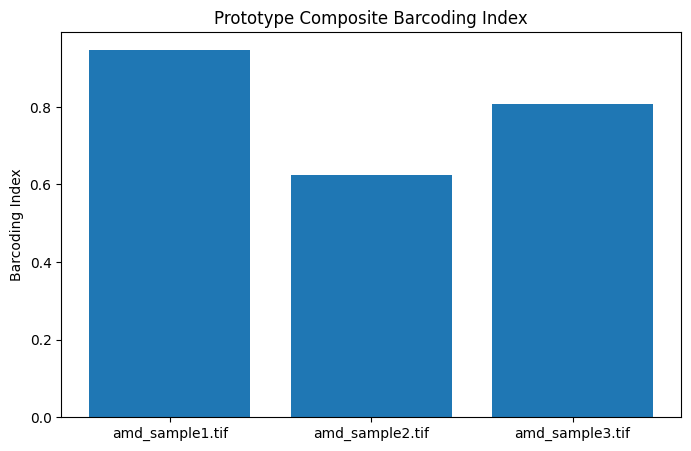

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    features_df["image"],
    features_df["barcoding_index"]
)

plt.ylabel("Barcoding Index")

plt.title(
    "Prototype Composite Barcoding Index"
)

plt.show()

We adjust the weights to test robustness: 
$$
BI_{\text{texture}}
=
0.4G
+
0.4A
+
0.1S
+
0.1P
$$

In [5]:
features_df["weighted_index"] = (

    0.10 * features_df["std_norm"]

    + 0.10 * features_df["peak_count_norm"]

    + 0.40 * features_df["gabor_score_norm"]

    + 0.40 * features_df["anisotropy_score_norm"]

)

features_df.sort_values(
    "weighted_index",
    ascending=False
)

,image,std,peak_count,gabor_score,anisotropy_score,std_norm,peak_count_norm,gabor_score_norm,anisotropy_score_norm,barcoding_index,weighted_index
0,amd_sample1.tif,0.025412,27,0.014115,0.430112,0.781595,1.000000,1.000000,1.000000,0.945399,0.978160
2,amd_sample3.tif,0.032513,27,0.004837,0.381750,1.000000,1.000000,0.342685,0.887560,0.807561,0.692098
1,amd_sample2.tif,0.019957,24,0.002806,0.341469,0.613816,0.888889,0.198796,0.793907,0.623852,0.547352


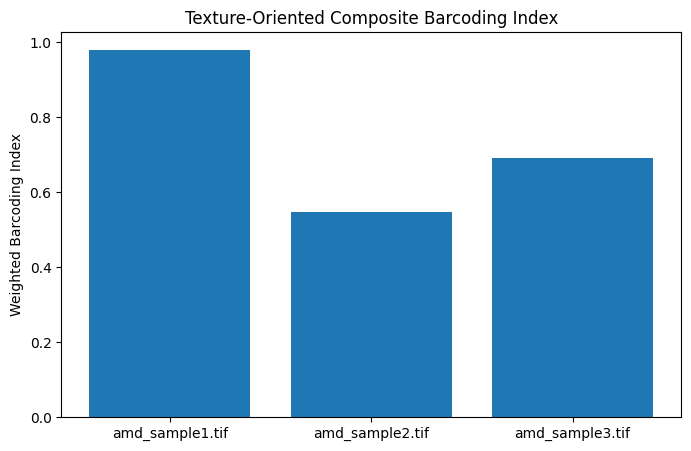

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    features_df["image"],
    features_df["weighted_index"]
)

plt.ylabel("Weighted Barcoding Index")

plt.title(
    "Texture-Oriented Composite Barcoding Index"
)

plt.show()

# Conclusions

This notebook investigated the construction of a composite barcoding index by combining multiple image-derived features developed throughout the preceding analyses.

## Summary of Features

The composite index integrates information from four complementary feature families:

- Transmission-profile variability (standard deviation),
- Local fluctuation density (peak count),
- Gabor-based texture measurements,
- Structure tensor anisotropy measurements.

These features were selected to capture different aspects of the barcoding phenomenon, including intensity variation, localized structure, directional texture, and spatial organization.

## Composite Index Performance

Two candidate indices were evaluated:

1. An equal-weight composite index.
2. A texture-oriented index emphasizing Gabor and anisotropy features.

Despite the different weighting strategies, both indices produced the same ranking:

$$
\text{Sample 1}
>
\text{Sample 3}
>
\text{Sample 2}.
$$

This consistency suggests that the observed ordering is not driven by any single feature and is relatively robust to reasonable changes in feature weighting.

## Interpretation

The agreement between:

- Visual inspection,
- Gabor texture analysis,
- Structure tensor anisotropy analysis,
- Composite feature aggregation,

provides preliminary evidence that the barcoding phenomenon contains measurable and reproducible image characteristics.

Furthermore, the results suggest that texture-based and directionality-based features contain substantially more information about barcoding severity than simple transmission-profile statistics alone.

## Limitations

Several important limitations remain:

- The analysis is based on only three representative OCT scans.
- ROI selection remains manually defined.
- Feature weights were chosen heuristically rather than learned from outcome data.
- No progression labels are currently available for validation.

Consequently, the present barcoding index should be viewed as a proof-of-concept quantitative measure rather than a finalized biomarker.

## Overall Conclusions

Across Notebooks 01–04, the barcoding phenomenon was investigated using progressively more sophisticated image-analysis techniques.

The analyses suggest that:

- Barcoding is not well described as a simple one-dimensional transmission signal.
- The phenomenon exhibits strong directional structure.
- Gabor filters successfully detect oriented transmission texture.
- Structure tensor analysis identifies coherent directional organization.
- Multiple independent methods produce consistent rankings across representative examples.
- These features can be combined into a unified quantitative barcoding index.

These findings provide a foundation for future work aimed at developing clinically useful barcoding biomarkers and evaluating their relationship to disease progression in age-related macular degeneration.